# PHƯƠNG PHÁP NGHIÊN CỨU & HUẤN LUYỆN MÔ HÌNH
**PHƯƠNG PHÁP NGHIÊN CỨU**: 
- Mục tiêu của phần này là xử lý các dữ liệu bị thiếu, chuyển đổi dữ liệu chữ sang số, và tiến hành huấn luyện 3 thuật toán học máy từ cơ bản đến nâng cao: **Linear Regression, Decision Tree và XGBoost**.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

# 1. Đọc và vá lỗi dữ liệu
df = pd.read_csv('data/raw/weatherHistory.csv')
df['Precip Type'] = df['Precip Type'].fillna(df['Precip Type'].mode()[0])

# 2. Dịch chữ sang số
le_summary = LabelEncoder()
le_precip = LabelEncoder()
df['Summary_Encoded'] = le_summary.fit_transform(df['Summary'])
df['Precip_Type_Encoded'] = le_precip.fit_transform(df['Precip Type'])


- **Nhận xét:** Dữ liệu đã sạch và sẵn sàng. Tiếp theo, nhóm chia dữ liệu thành 2 tập: **80% để huấn luyện (Train)** và **20% để kiểm thử (Test)**.


**Huấn luyện các mô hình AI**
- Nhóm sử dụng 3 thuật toán với mức độ phức tạp tăng dần để so sánh:
1. **Linear Regression:** Hồi quy tuyến tính (Mô hình cơ sở).
2. **Decision Tree:** Cây quyết định (Mô hình trung bình).
3. **XGBoost:** Thuật toán tăng cường (Mô hình nâng cao).

In [6]:
# Chọn đầu vào (X) và đầu ra cần đoán (y)
X = df[['Humidity', 'Wind Speed (km/h)', 'Pressure (millibars)', 'Summary_Encoded', 'Precip_Type_Encoded']]
y = df['Temperature (C)']

# Chia bài 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# 2. Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# 3. XGBoost
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)


**KẾT QUẢ VÀ ĐÁNH GIÁ**
Để đánh giá độ chính xác của 3 mô hình, nhóm sử dụng chỉ số **R-squared** ($R^2$). Chỉ số này càng gần 1 (100%), mô hình dự báo càng chuẩn xác.

Công thức tính $R^2$:
$$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18632\3255390643.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=scores, palette=['coral', 'skyblue', 'mediumseagreen'])


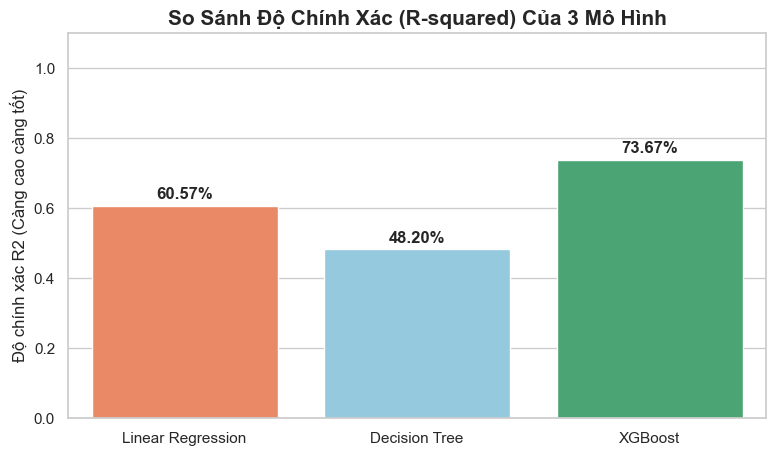

In [7]:
# Tính điểm
lr_r2 = r2_score(y_test, lr_pred)
dt_r2 = r2_score(y_test, dt_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

# Vẽ biểu đồ
plt.figure(figsize=(9, 5))
models = ['Linear Regression', 'Decision Tree', 'XGBoost']
scores = [lr_r2, dt_r2, xgb_r2]

sns.barplot(x=models, y=scores, palette=['coral', 'skyblue', 'mediumseagreen'])
plt.title('So Sánh Độ Chính Xác (R-squared) Của 3 Mô Hình', fontsize=15, fontweight='bold')
plt.ylabel('Độ chính xác R2 (Càng cao càng tốt)')
plt.ylim(0, 1.1)

for i, v in enumerate(scores):
    plt.text(i, v + 0.02, f"{v*100:.2f}%", ha='center', fontsize=12, fontweight='bold')

plt.show()

**Nhận xét :**
Nhìn vào biểu đồ so sánh, ta thấy rõ sự chênh lệch hiệu năng:
- **Linear Regression** đạt điểm thấp nhất, cho thấy mối quan hệ giữa thời tiết và nhiệt độ không phải là đường thẳng đơn giản.
- **Decision Tree** có sự cải thiện đáng kể nhờ khả năng rẽ nhánh logic.
- **XGBoost** thể hiện sức mạnh vượt trội nhất, đạt độ chính xác cao nhất trong cả 3 mô hình.

**Kết luận:** Nhóm quyết định chọn thuật toán **XGBoost** làm mô hình chính thức để đóng gói và triển khai lên ứng dụng Web.